In [11]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

try:
    nltk.data.find('sentiment/vader_lexicon.zip')
except LookupError:
    nltk.download('vader_lexicon')


--- Generating GME Full History Plot (Contextual) ---


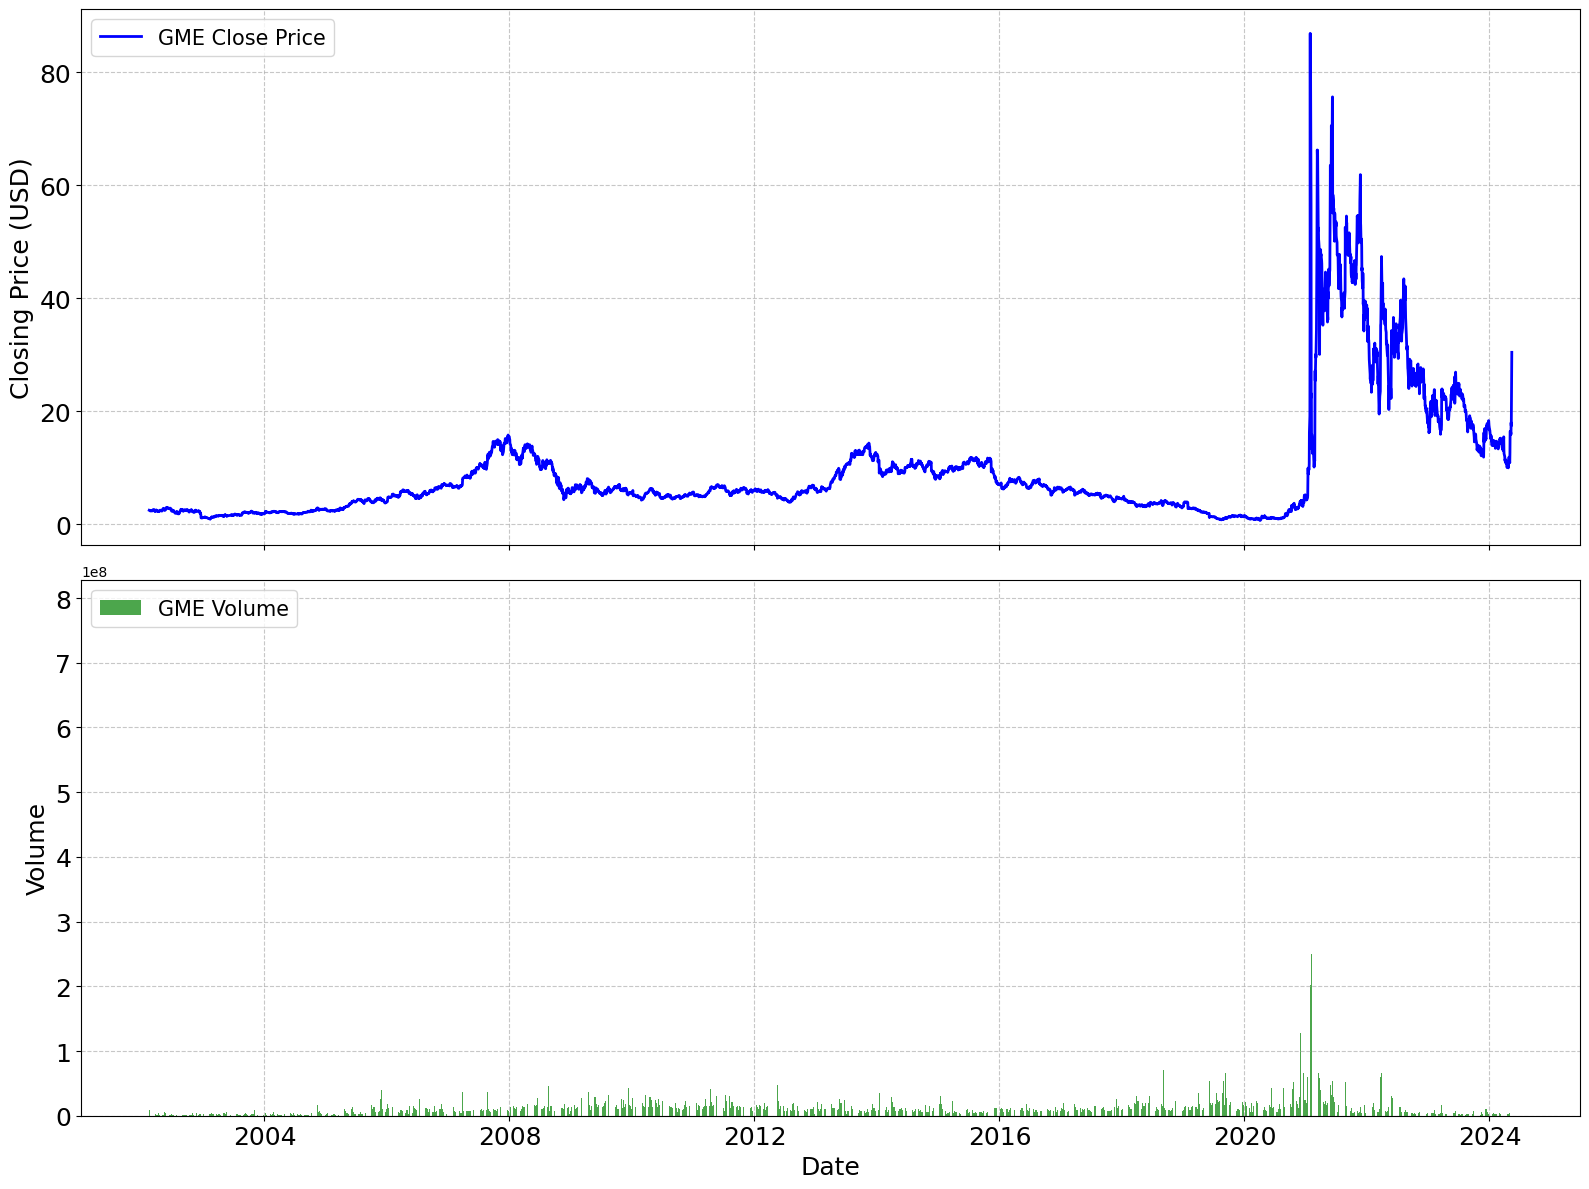


Full GME History Plot (Contextual) generated. Save this image for your report's context if desired.


In [12]:
gme_stock_file = os.path.join(os.getcwd(), 'GameStop.csv')

print("\n--- Generating GME Full History Plot (Contextual) ---")

if not os.path.exists(gme_stock_file):
    print(f"Error: GME stock file not found at '{gme_stock_file}'. Please check the path.")
else:
    try:
        df_gme_full = pd.read_csv(gme_stock_file)
        df_gme_full['Date'] = pd.to_datetime(df_gme_full['Date'])
        df_gme_full.set_index('Date', inplace=True)

        fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

        axes[0].plot(df_gme_full.index, df_gme_full['Close'], label='GME Close Price', color='blue', linewidth=2)
        axes[0].set_ylabel('Closing Price (USD)', fontsize=18)
        axes[0].tick_params(axis='both', which='major', labelsize=18)
        axes[0].grid(True, linestyle='--', alpha=0.7)
        axes[0].legend(loc='upper left', fontsize=15)

        axes[1].bar(df_gme_full.index, df_gme_full['Volume'], label='GME Volume', color='green', alpha=0.7)
        axes[1].set_xlabel('Date', fontsize=18)
        axes[1].set_ylabel('Volume', fontsize=18)
        axes[1].tick_params(axis='both', which='major', labelsize=18)
        axes[1].grid(True, linestyle='--', alpha=0.7)
        axes[1].legend(loc='upper left', fontsize=15)

        plt.tight_layout()
        plt.show()

        print("\nFull GME History Plot (Contextual) generated. Save this image for your report's context if desired.")

    except Exception as e:
        print(f"An error occurred while processing full GME stock data: {e}")
        print("Please ensure 'GameStop.csv' is valid and contains 'Date', 'Close', and 'Volume' columns.")


--- Generating Report Figure 1: GME Stock Price and Volume History (Focused) ---


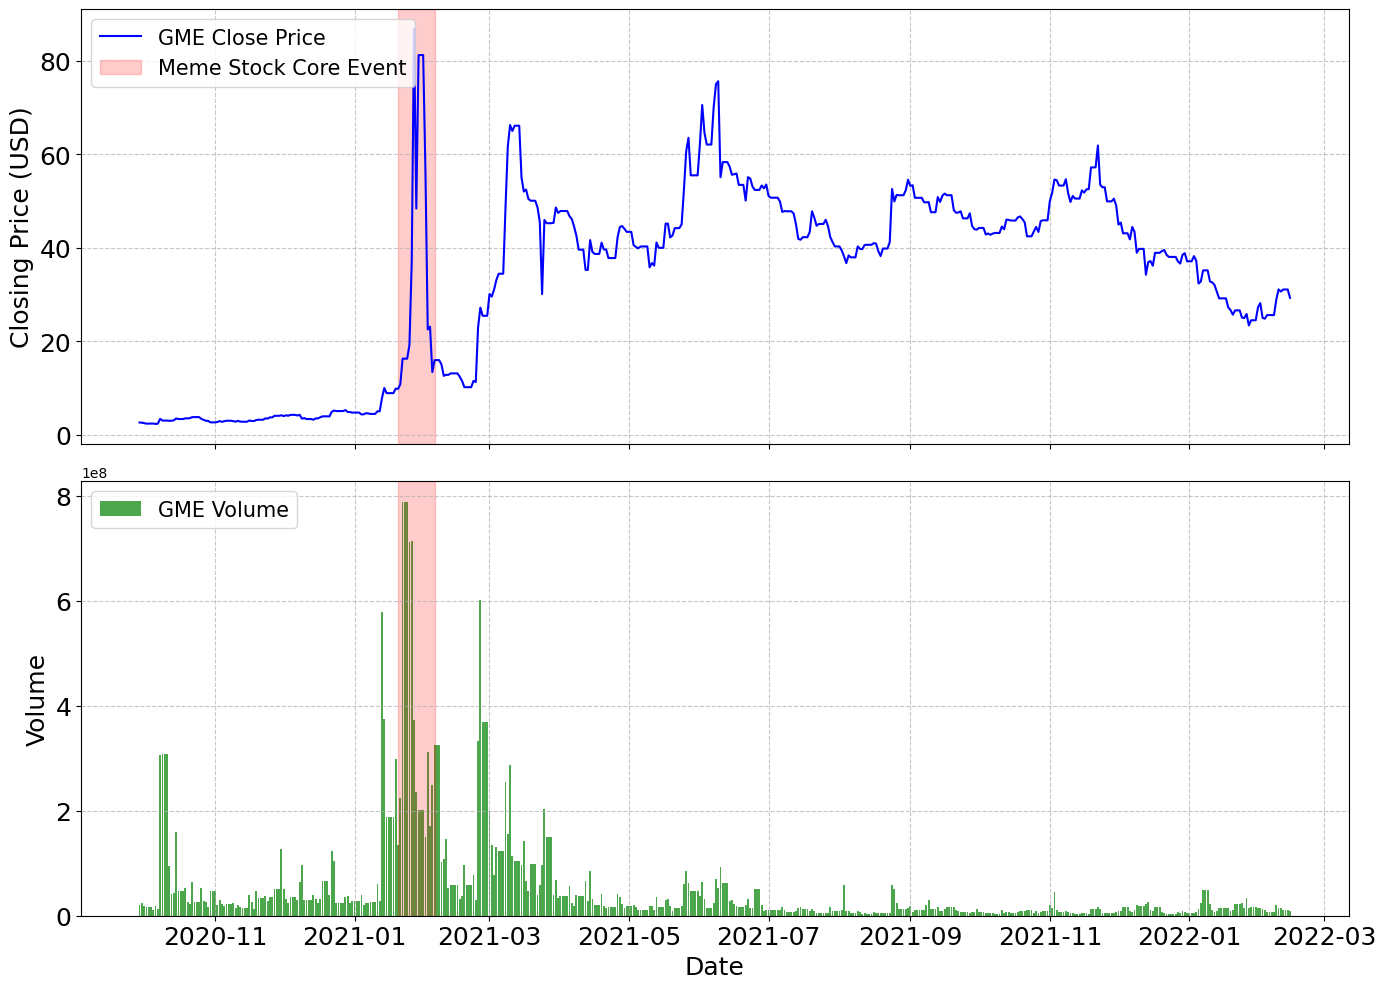


Figure 1 generated for range 2020-09-29 00:00:00 to 2022-02-14 00:00:00. Save this image for your report.


In [13]:
gme_stock_file = os.path.join(os.getcwd(), 'GameStop.csv')

print("\n--- Generating Report Figure 1: GME Stock Price and Volume History (Focused) ---")

focused_start_date_report = '2020-09-29'
focused_end_date_report = '2022-02-14'
meme_core_start_report = '2021-01-20'
meme_core_end_report = '2021-02-05'

if not os.path.exists(gme_stock_file):
    print(f"Error: GME stock file not found at '{gme_stock_file}'. Please check the path.")
else:
    try:
        df_gme_report = pd.read_csv(gme_stock_file)
        df_gme_report['Date'] = pd.to_datetime(df_gme_report['Date'])
        df_gme_report.set_index('Date', inplace=True)

        df_gme_report_daily = df_gme_report[['Close', 'Volume']].resample('D').mean()
        df_gme_report_daily.fillna(method='ffill', inplace=True)

        df_gme_plot_report = df_gme_report_daily.loc[focused_start_date_report:focused_end_date_report].sort_index().copy()

        if df_gme_plot_report.empty:
            print(f"No GME data found within the focused period ({focused_start_date_report} - {focused_end_date_report}). Check data or dates.")
        else:
            fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

            axes[0].plot(df_gme_plot_report.index, df_gme_plot_report['Close'], label='GME Close Price', color='blue')
            axes[0].set_ylabel('Closing Price (USD)', fontsize=18)
            axes[0].tick_params(axis='both', which='major', labelsize=18)
            axes[0].grid(True, linestyle='--', alpha=0.7)
            axes[0].legend(loc='upper left', fontsize=15)

            axes[0].axvspan(pd.to_datetime(meme_core_start_report), pd.to_datetime(meme_core_end_report),
                            color='red', alpha=0.2, label='Meme Stock Core Event')
            axes[0].legend(loc='upper left', fontsize=15)

            axes[1].bar(df_gme_plot_report.index, df_gme_plot_report['Volume'], label='GME Volume', color='green', alpha=0.7)
            axes[1].set_xlabel('Date', fontsize=18)
            axes[1].set_ylabel('Volume', fontsize=18)
            axes[1].tick_params(axis='both', which='major', labelsize=18)
            axes[1].grid(True, linestyle='--', alpha=0.7)
            axes[1].legend(loc='upper left', fontsize=15)

            axes[1].axvspan(pd.to_datetime(meme_core_start_report), pd.to_datetime(meme_core_end_report),
                            color='red', alpha=0.2)

            plt.tight_layout()
            plt.show()

            print(f"\nFigure 1 generated for range {df_gme_plot_report.index.min()} to {df_gme_plot_report.index.max()}. Save this image for your report.")

    except Exception as e:
        print(f"An error occurred while processing GME stock data for Figure 1: {e}")
        print("Please ensure 'GameStop.csv' is a valid CSV and contains 'Date', 'Close', and 'Volume' columns.")